In [3]:
import sys
import os
# Add the project root to Python path (assuming we're in tests/tests_mcts/)
project_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

from src.algos.mcts import evaluate
import numpy as np
import matplotlib.pyplot as plt
import time
import pandas as pd

def run_symmetry_comparison_experiment():
    """
    Experiment to compare how different max_level_to_use_symmetry values affect running time
    """
    # Fixed parameters for the experiment
    n = 10  # Grid size
    num_trials = 3  # Number of trials per symmetry level for averaging
    
    # Different symmetry levels to test
    symmetry_levels = [0, 1, 2, 3, 5, 10]  # 0 = no symmetry, higher = more symmetry usage
    
    results = []
    
    print(f"Starting symmetry comparison experiment for n={n}")
    print(f"Testing symmetry levels: {symmetry_levels}")
    print(f"Number of trials per level: {num_trials}")
    print("=" * 60)
    
    for max_symmetry in symmetry_levels:
        print(f"\nTesting max_level_to_use_symmetry = {max_symmetry}")
        
        trial_times = []
        trial_points = []
        
        for trial in range(num_trials):
            print(f"  Trial {trial + 1}/{num_trials}...", end=" ")
            
            args = {
                'environment': 'N3il_with_symmetry',
                'algorithm': 'MCTS',
                'max_level_to_use_symmetry': max_symmetry,
                'n': n,
                'C': 1.41,
                'num_searches': 50*(n**2),  # Reduced for faster experiments
                'num_workers': 4,  # Reduced for more controlled timing
                'virtual_loss': 1.0,
                'process_bar': False,  # Disable progress bar for cleaner output
                'display_state': False,  # Disable state display for cleaner output
                'logging_mode': True,  # Enable to get return value
                'TopN': n,
                "simulate_with_priority": False,
                'table_dir': f'tests/tests_mcts',
                'figure_dir': f'tests/tests_mcts/figure',
                'random_seed': trial + max_symmetry * 100,  # Ensure different seeds
            }
            
            # Measure execution time
            start_time = time.time()
            num_points = evaluate(args)
            end_time = time.time()
            
            execution_time = end_time - start_time
            trial_times.append(execution_time)
            trial_points.append(num_points)
            
            print(f"Time: {execution_time:.2f}s, Points: {num_points}")
        
        # Calculate statistics for this symmetry level
        avg_time = np.mean(trial_times)
        std_time = np.std(trial_times)
        avg_points = np.mean(trial_points)
        
        results.append({
            'max_symmetry': max_symmetry,
            'avg_time': avg_time,
            'std_time': std_time,
            'avg_points': avg_points,
            'trial_times': trial_times,
            'trial_points': trial_points
        })
        
        print(f"  Average time: {avg_time:.2f}±{std_time:.2f}s")
        print(f"  Average points: {avg_points:.1f}")
    
    return results

# Run the experiment
experiment_results = run_symmetry_comparison_experiment()

2.2.5
2.2.5
Starting symmetry comparison experiment for n=10
Testing symmetry levels: [0, 1, 2, 3, 5, 10]
Number of trials per level: 3

Testing max_level_to_use_symmetry = 0
  Trial 1/3... 2.2.5
Starting symmetry comparison experiment for n=10
Testing symmetry levels: [0, 1, 2, 3, 5, 10]
Number of trials per level: 3

Testing max_level_to_use_symmetry = 0
  Trial 1/3... *******************************************************************
Trial Terminated with 19 points. Final valid configuration:
[[0 0 0 1 0 1 0 0 0 0]
 [0 0 0 0 0 1 0 1 0 0]
 [0 1 0 0 0 0 1 0 0 0]
 [0 0 1 0 0 0 0 0 1 0]
 [1 0 0 0 0 0 1 0 0 0]
 [0 0 1 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 1]
 [0 0 0 0 0 0 0 0 1 1]
 [0 1 0 0 1 0 0 0 0 0]
 [0 0 0 1 1 0 0 0 0 0]]
Plot saved as: tests/tests_mcts/figure/20250805_102951_10by10/no_three_in_line_10x10_pts19_MCTS_20250805_102951.png (DPI: 150)
Time: 1.662471 sec
Results recorded to: tests/tests_mcts/experiment_results.csv
Time: 1.76s, Points: 19
  Trial 2/3... *********************

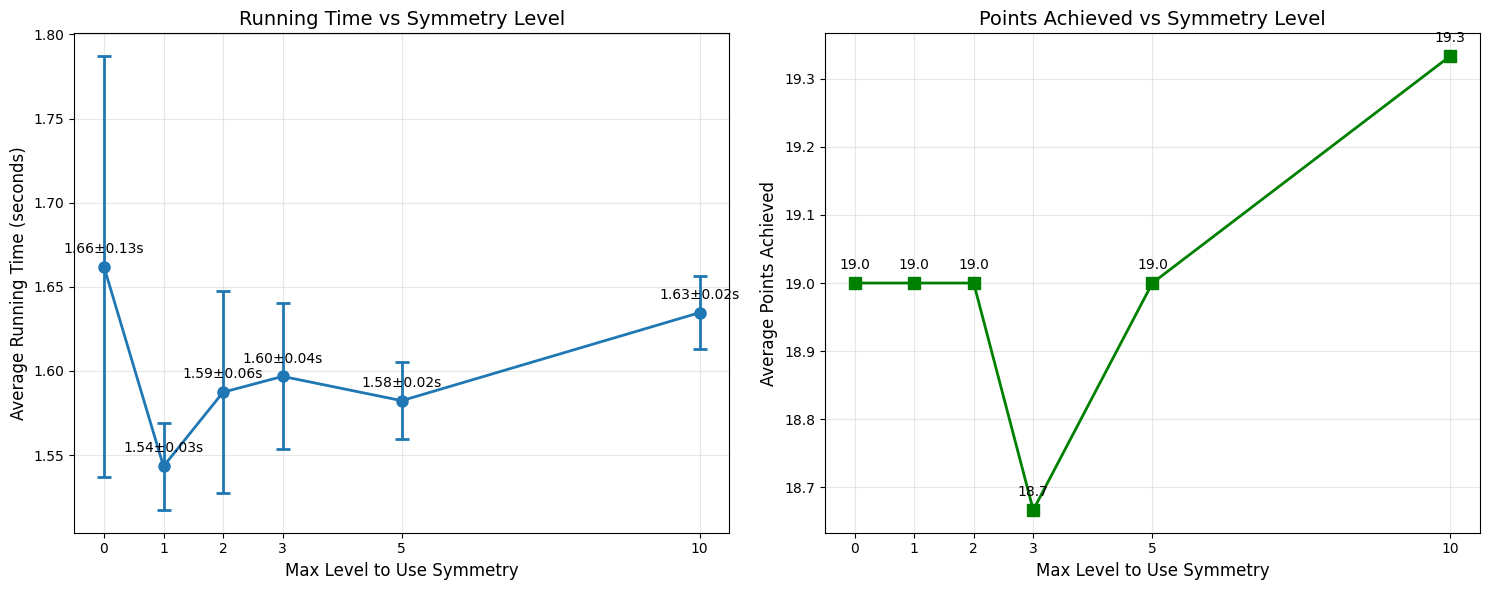


DETAILED RESULTS SUMMARY
 Symmetry Level Avg Time (s) Std Time (s) Avg Points Time vs No-Symmetry
              0         1.66         0.13       19.0               1.00x
              1         1.54         0.03       19.0               0.93x
              2         1.59         0.06       19.0               0.96x
              3         1.60         0.04       18.7               0.96x
              5         1.58         0.02       19.0               0.95x
             10         1.63         0.02       19.3               0.98x

ANALYSIS INSIGHTS
• Baseline (no symmetry): 1.66s
• Fastest configuration: max_symmetry=1 at 1.54s
• Speed improvement: 1.08x faster
• Time reduction: 7.1%
• Point consistency: High (std=0.19) - symmetry doesn't affect solution quality


In [6]:
# Plot the results
def plot_symmetry_results(results):
    """
    Plot the results of the symmetry comparison experiment
    """
    # Extract data for plotting
    symmetry_levels = [r['max_symmetry'] for r in results]
    avg_times = [r['avg_time'] for r in results]
    std_times = [r['std_time'] for r in results]
    avg_points = [r['avg_points'] for r in results]
    
    # Create figure with subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Plot 1: Running time vs symmetry level
    ax1.errorbar(symmetry_levels, avg_times, yerr=std_times, 
                marker='o', capsize=5, capthick=2, linewidth=2, markersize=8)
    ax1.set_xlabel('Max Level to Use Symmetry', fontsize=12)
    ax1.set_ylabel('Average Running Time (seconds)', fontsize=12)
    ax1.set_title('Running Time vs Symmetry Level', fontsize=14)
    ax1.grid(True, alpha=0.3)
    ax1.set_xticks(symmetry_levels)
    
    # Add value labels on points
    for i, (x, y, err) in enumerate(zip(symmetry_levels, avg_times, std_times)):
        ax1.annotate(f'{y:.2f}±{err:.2f}s', 
                    (x, y), textcoords="offset points", 
                    xytext=(0,10), ha='center', fontsize=10)
    
    # Plot 2: Average points achieved vs symmetry level
    ax2.plot(symmetry_levels, avg_points, marker='s', linewidth=2, markersize=8, color='green')
    ax2.set_xlabel('Max Level to Use Symmetry', fontsize=12)
    ax2.set_ylabel('Average Points Achieved', fontsize=12)
    ax2.set_title('Points Achieved vs Symmetry Level', fontsize=14)
    ax2.grid(True, alpha=0.3)
    ax2.set_xticks(symmetry_levels)
    
    # Add value labels on points
    for i, (x, y) in enumerate(zip(symmetry_levels, avg_points)):
        ax2.annotate(f'{y:.1f}', 
                    (x, y), textcoords="offset points", 
                    xytext=(0,10), ha='center', fontsize=10)
    
    plt.tight_layout()
    plt.savefig('tests/tests_mcts/figure/symmetry_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Create detailed results table
    print("\n" + "="*80)
    print("DETAILED RESULTS SUMMARY")
    print("="*80)
    
    df_results = pd.DataFrame({
        'Symmetry Level': symmetry_levels,
        'Avg Time (s)': [f'{t:.2f}' for t in avg_times],
        'Std Time (s)': [f'{t:.2f}' for t in std_times],
        'Avg Points': [f'{p:.1f}' for p in avg_points],
        'Time vs No-Symmetry': [f'{t/avg_times[0]:.2f}x' for t in avg_times]
    })
    
    print(df_results.to_string(index=False))
    
    # Calculate and display insights
    print(f"\n" + "="*80)
    print("ANALYSIS INSIGHTS")
    print("="*80)
    
    baseline_time = avg_times[0]  # No symmetry case
    min_time_idx = np.argmin(avg_times)
    min_time = avg_times[min_time_idx]
    best_symmetry = symmetry_levels[min_time_idx]
    
    print(f"• Baseline (no symmetry): {baseline_time:.2f}s")
    print(f"• Fastest configuration: max_symmetry={best_symmetry} at {min_time:.2f}s")
    print(f"• Speed improvement: {baseline_time/min_time:.2f}x faster")
    print(f"• Time reduction: {((baseline_time-min_time)/baseline_time)*100:.1f}%")
    
    # Points analysis
    points_std = np.std(avg_points)
    if points_std < 1.0:
        print(f"• Point consistency: High (std={points_std:.2f}) - symmetry doesn't affect solution quality")
    else:
        print(f"• Point consistency: Variable (std={points_std:.2f}) - some impact on solution quality")

# Plot the results
plot_symmetry_results(experiment_results)

In [5]:
# Optional: Plot individual trial data for more detailed analysis
def plot_individual_trials(results):
    """
    Plot individual trial data to show variability
    """
    fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    
    # Plot individual trials as scatter points
    for i, result in enumerate(results):
        symmetry_level = result['max_symmetry']
        trial_times = result['trial_times']
        
        # Add some jitter for better visualization
        x_positions = [symmetry_level + np.random.normal(0, 0.1) for _ in trial_times]
        ax.scatter(x_positions, trial_times, alpha=0.6, s=50, label=f'Level {symmetry_level}')
    
    # Plot averages as a line
    symmetry_levels = [r['max_symmetry'] for r in results]
    avg_times = [r['avg_time'] for r in results]
    ax.plot(symmetry_levels, avg_times, 'k-', linewidth=3, marker='D', 
            markersize=10, label='Average', zorder=10)
    
    ax.set_xlabel('Max Level to Use Symmetry', fontsize=12)
    ax.set_ylabel('Running Time (seconds)', fontsize=12)
    ax.set_title('Individual Trial Results: Running Time vs Symmetry Level', fontsize=14)
    ax.grid(True, alpha=0.3)
    ax.set_xticks(symmetry_levels)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    plt.savefig('tests/tests_mcts/figure/symmetry_individual_trials.png', dpi=300, bbox_inches='tight')
    plt.show()

# Uncomment the line below to see individual trial variability
# plot_individual_trials(experiment_results)